# DBSCAN Clustering

## Blocks
1. Categorical preprocessing (one-hot)
2. Outlier detection and removal
3. Scaling and clustering
4. Silhouette and PCA visualization

## 1) Imports and Shared Helpers

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_dataset_path():
    candidates = [
        Path.cwd() / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent.parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Cannot find Mushroom Dataset/mushrooms 2.csv from current location.')

def load_and_clean_data(rare_threshold=0.01):
    df = pd.read_csv(resolve_dataset_path())
    df = df.replace('?', np.nan).drop_duplicates().copy()

    for c in df.columns:
        if df[c].isna().any():
            if pd.api.types.is_numeric_dtype(df[c]):
                df[c] = df[c].fillna(df[c].mean())
            else:
                mode_val = df[c].mode(dropna=True)
                df[c] = df[c].fillna(mode_val.iloc[0] if not mode_val.empty else 'missing')

    outlier_mask = pd.Series(False, index=df.index)
    outlier_cols = []
    min_count = max(1, int(rare_threshold * len(df)))

    for c in df.columns:
        if c == 'class':
            continue
        counts = df[c].value_counts(dropna=False)
        rare_vals = counts[counts < min_count].index
        if len(rare_vals) > 0:
            is_rare = df[c].isin(rare_vals)
            outlier_mask = outlier_mask | is_rare
            outlier_cols.append(c)

    df['is_outlier'] = outlier_mask.astype(int)
    single_cols = [c for c in df.columns if c != 'is_outlier' and df[c].nunique() <= 1]
    if single_cols:
        df = df.drop(columns=single_cols)

    return df, outlier_cols
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import DBSCAN

## 2) Clustering Pipeline

Silhouette unavailable for current eps/min_samples
Noise ratio: 1.0
Clusters found: 0
Outlier columns: ['cap-shape', 'cap-surface', 'cap-color', 'odor', 'gill-color', 'stalk-surface-above-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color']


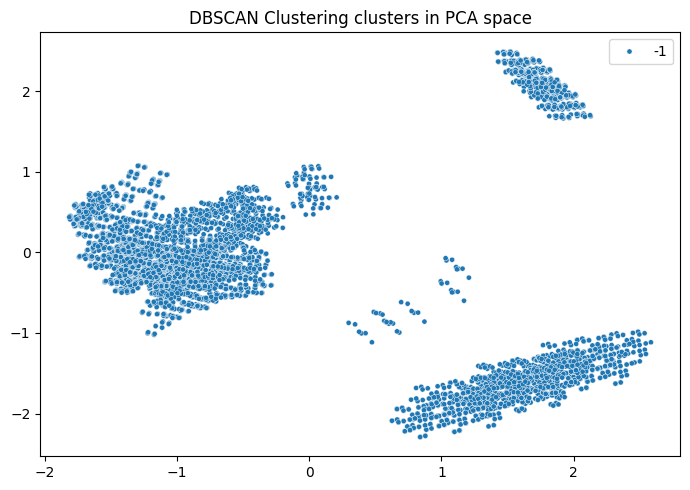

In [2]:
df_all, outlier_cols = load_and_clean_data(rare_threshold=0.01)
df = df_all[df_all['is_outlier'] == 0].drop(columns=['is_outlier']).copy()
y_true = df['class'].map({'e': 0, 'p': 1}).astype(int)
X_raw = df.drop(columns=['class'])

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X = ohe.fit_transform(X_raw)
X = MinMaxScaler().fit_transform(X)

model = DBSCAN(eps=0.35, min_samples=10, metric='euclidean')
labels = model.fit_predict(X)
valid = labels != -1
if valid.sum() > 1 and len(np.unique(labels[valid])) > 1:
    print('Silhouette (non-noise):', round(silhouette_score(X[valid], labels[valid]), 4))
else:
    print('Silhouette unavailable for current eps/min_samples')
print('Noise ratio:', round(float((labels == -1).mean()), 4))
print('Clusters found:', len(set(labels)) - (1 if -1 in labels else 0))

print('Outlier columns:', outlier_cols)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=labels, palette='tab10', s=14)
plt.title('DBSCAN Clustering clusters in PCA space')
plt.tight_layout()
plt.show()